In [12]:
## Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score


In [13]:
## Load & Split Data
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
## Bagian A – Boosting
## AdaBoost
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train_scaled, y_train)

acc_ada = accuracy_score(y_test, ada.predict(X_test_scaled))
print("AdaBoost Accuracy:", acc_ada)

AdaBoost Accuracy: 0.9736842105263158


In [15]:
##  Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)

acc_gb = accuracy_score(y_test, gb.predict(X_test_scaled))
print("Gradient Boosting Accuracy:", acc_gb)

Gradient Boosting Accuracy: 0.956140350877193


In [16]:
## Bagian B – Voting Classifier
## Voting (Soft Voting)
log = LogisticRegression(max_iter=5000)
rf = RandomForestClassifier(n_estimators=100)
gb = GradientBoostingClassifier(n_estimators=100)

voting = VotingClassifier(
    estimators=[('log', log), ('rf', rf), ('gb', gb)],
    voting='soft'
)

voting.fit(X_train_scaled, y_train)

acc_vote = accuracy_score(y_test, voting.predict(X_test_scaled))
print("Voting Accuracy:", acc_vote)


Voting Accuracy: 0.9649122807017544


In [17]:
##  Bagian C – Hyperparameter Tuning
##  GridSearch (Random Forest)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


Best Parameters: {'max_depth': None, 'n_estimators': 200}
Best CV Score: 0.9604395604395604


In [18]:
## Bagian D – PCA + Ensemble
## Terapkan PCA
pca = PCA(n_components=10)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

gb_pca = GradientBoostingClassifier(n_estimators=100)
gb_pca.fit(X_train_pca, y_train)

acc_gb_pca = accuracy_score(y_test, gb_pca.predict(X_test_pca))
print("Gradient Boosting + PCA:", acc_gb_pca)

Gradient Boosting + PCA: 0.9473684210526315


In [19]:
##Bagian E – Tabel Perbandingan Akhir
## Logistic Regression
log_single = LogisticRegression(max_iter=5000)

log_single.fit(X_train_scaled, y_train)

acc_log = accuracy_score(
    y_test,
    log_single.predict(X_test_scaled)
)

print("Logistic Accuracy:", acc_log)

##Random Forest
rf_single = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_single.fit(X_train_scaled, y_train)

acc_rf = accuracy_score(
    y_test,
    rf_single.predict(X_test_scaled)
)

print("Random Forest Accuracy:", acc_rf)

## Best Tuned Model
best_model = grid.best_estimator_

acc_best = accuracy_score(
    y_test,
    best_model.predict(X_test_scaled)
)

print("Best Tuned Model Accuracy:", acc_best)

Logistic Accuracy: 0.9736842105263158
Random Forest Accuracy: 0.9649122807017544
Best Tuned Model Accuracy: 0.9649122807017544


In [20]:
## Tabel Perbandingan Akhir
comparison_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting",
        "Voting Classifier",
        "Best Tuned Model",
        "Gradient Boosting + PCA"
    ],
    "Accuracy": [
        acc_log,
        acc_rf,
        acc_ada,
        acc_gb,
        acc_vote,
        acc_best,
        acc_gb_pca
    ]
})

comparison_table

,Model,Accuracy
0,Logistic Regression,0.973684
1,Random Forest,0.964912
2,AdaBoost,0.973684
3,Gradient Boosting,0.956140
4,Voting Classifier,0.964912
5,Best Tuned Model,0.964912
6,Gradient Boosting + PCA,0.947368


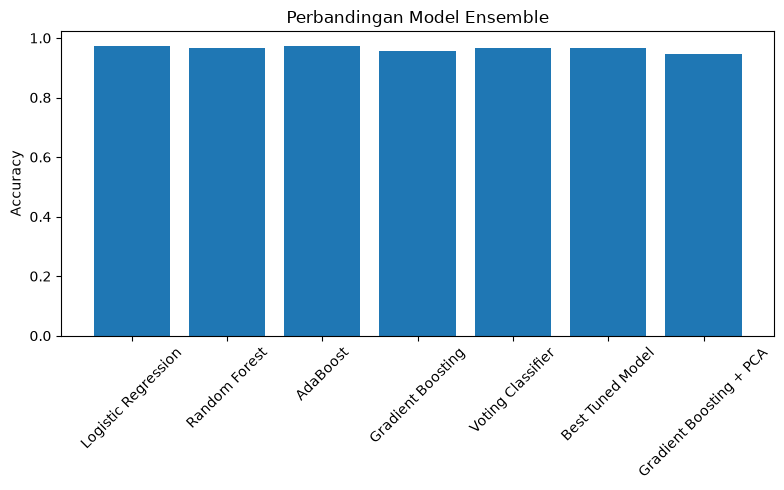

In [21]:
## Grafik Perbandingan Model
plt.figure(figsize=(8,5))

plt.bar(
    comparison_table["Model"],
    comparison_table["Accuracy"]
)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title("Perbandingan Model Ensemble")

plt.tight_layout()

plt.show()